# Accelerated Failure Time (AFT) Models in R

## Overview

AFT models are parametric survival models that specify a distribution for the event times. Instead of hazard ratios, they produce **time ratios** — more interpretable in many applied settings.

$$\log(T) = \beta_0 + \beta_1 X_1 + \ldots + \sigma \varepsilon$$

The **time ratio** $\exp(\beta)$: the factor by which the event time is multiplied per unit increase in X.
- TR > 1: covariate *extends* time to event (protective — event takes longer)
- TR < 1: covariate *shortens* time to event (harmful — event happens sooner)

**Available distributions:**

| Distribution | Shape | When to use |
|---|---|---|
| **Exponential** | Constant hazard | Memoryless process; simplest |
| **Weibull** | Monotone increasing or decreasing hazard | Most commonly used; includes exponential as special case |
| **Log-normal** | Non-monotone hazard (rises then falls) | Biological processes with acceleration then deceleration |
| **Log-logistic** | Non-monotone hazard; heavier tail than log-normal | When hazard peaks and then decreases |
| **Gamma** | Flexible; includes exponential and log-normal | General purpose |

**AFT vs. Cox:**
- Cox: semi-parametric (no distribution for $h_0$); produces HRs; robust to distribution misspecification
- AFT: parametric (distribution must be specified and checked); produces time ratios; more efficient when distribution is correct; better extrapolation

---

## Setup

In [6]:
library(tidyverse)
library(survival)
library(flexsurv)
library(survminer)
library(broom)

set.seed(42)

# ── Simulate Weibull-distributed colonisation times ───────────────────────────
n <- 200
aft_data <- tibble(
  id          = 1:n,
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace = TRUE, prob = c(0.35, 0.35, 0.30)),
                       levels = c("reference","restored","degraded")),
  water_qual  = rnorm(n, 6, 1.5),
  distance_km = rexp(n, 0.3)
) %>%
  mutate(
    log_scale = 3.5 +
                  case_when(habitat == "reference" ~ 0,
                            habitat == "restored"  ~ -0.3,
                            habitat == "degraded"  ~ -0.8) +
                  0.25 * water_qual - 0.12 * distance_km,
    true_t  = rweibull(n, shape = 1.8, scale = exp(log_scale)),
    status  = as.integer(true_t <= 60),
    time    = pmin(true_t, 60)
  )

cat(sprintf("%d / %d events observed\n", sum(aft_data$status), n))

101 / 200 events observed


---

## Step 1: Select the Best Distribution

# A tibble: 5 × 4
  distribution   AIC logLik delta_AIC
  <chr>        <dbl>  <dbl>     <dbl>
1 llogis        983.  -485.      0   
2 gamma         984.  -486.      1.67
3 weibull       987.  -488.      4.64
4 lnorm         991.  -490.      8.7 
5 exponential  1019.  -505.     36.7 


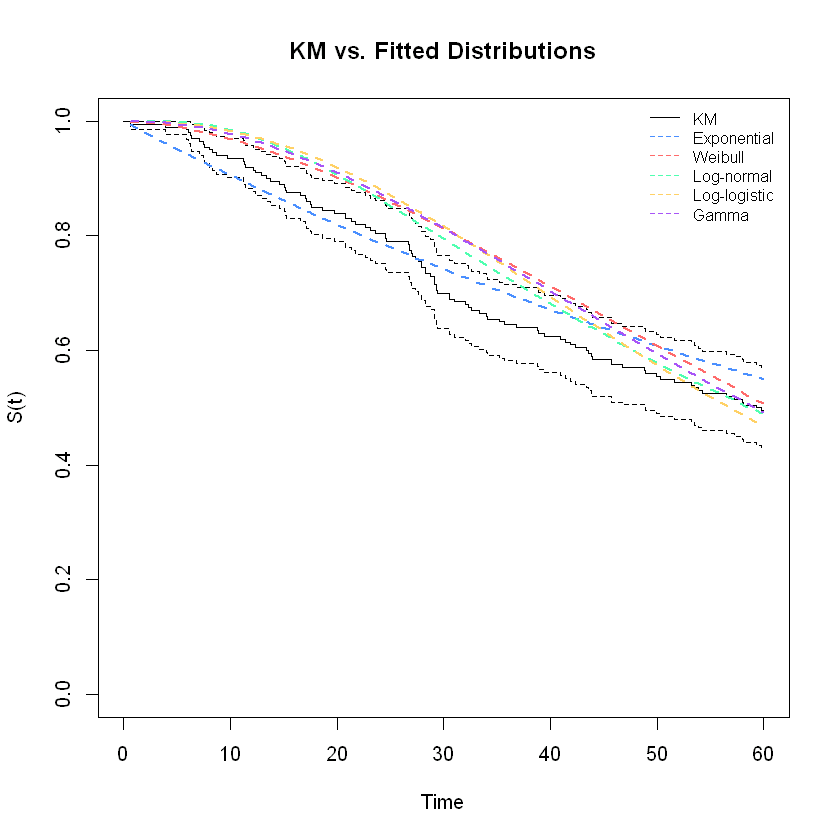

In [7]:
# ── Fit all major distributions and compare by AIC ────────────────────────────
# Correct flexsurv distribution names: llogis not loglogistic, lnorm not lognormal
distributions <- c("exponential", "weibull", "lnorm", "llogis", "gamma")
dist_labels   <- c("Exponential", "Weibull", "Log-normal", "Log-logistic", "Gamma")

dist_fits <- map(distributions, function(d) {
  flexsurv::flexsurvreg(
    Surv(time, status) ~ habitat + water_qual + distance_km,
    data = aft_data, dist = d
  )
}) %>% setNames(distributions)

aic_table <- map_dfr(names(dist_fits), function(nm) {
  tibble(
    distribution = nm,
    AIC          = AIC(dist_fits[[nm]]),
    logLik       = round(as.numeric(logLik(dist_fits[[nm]])), 2)
  )
}) %>% arrange(AIC) %>% mutate(delta_AIC = round(AIC - min(AIC), 2))
print(aic_table)

# ── Visual check: overlay fitted distributions on KM curve ───────────────────
km_check <- survfit(Surv(time, status) ~ 1, data = aft_data)
plot(km_check, xlab = "Time", ylab = "S(t)", main = "KM vs. Fitted Distributions")
cols <- c("#4a8fff", "#ff6b6b", "#4fffb0", "#ffd166", "#a855f7")
for (i in seq_along(distributions)) {
  lines(dist_fits[[i]], col = cols[i], lty = 2, ci = FALSE)
}
legend("topright", legend = c("KM", dist_labels),
       col = c("black", cols), lty = c(1, rep(2, 5)), bty = "n", cex = 0.8)

---

## Step 2: Fit the Best AFT Model

In [8]:
# Fit best-selected distribution (Weibull here by construction)
best_aft <- flexsurv::flexsurvreg(
  Surv(time, status) ~ habitat + water_qual + distance_km,
  data = aft_data,
  dist = "weibull"
)
print(best_aft)
# Coefficients on the log(time) scale
# exp(coef) = time ratio

# ── Extract time ratios ───────────────────────────────────────────────────────
tr_table <- tibble(
  term         = names(coef(best_aft)),
  log_estimate = coef(best_aft),
  time_ratio   = exp(coef(best_aft)),
  ci_low       = exp(confint(best_aft)[,1]),
  ci_high      = exp(confint(best_aft)[,2])
) %>%
  filter(!term %in% c("shape")) %>%
  mutate(across(c(time_ratio, ci_low, ci_high), ~round(.x, 3)))
print(tr_table)

# ── Interpretation ────────────────────────────────────────────────────────────
cat("\nTime ratio interpretation:\n")
cat("  TR > 1: covariate DELAYS the event (protective — longer survival)\n")
cat("  TR < 1: covariate ACCELERATES the event (harmful — shorter survival)\n")
cat("  TR = 1.5 for habitat=restored: restored sites have 1.5x longer median\n")
cat("           colonisation time compared to reference sites\n")

Call:
flexsurv::flexsurvreg(formula = Surv(time, status) ~ habitat + 
    water_qual + distance_km, data = aft_data, dist = "weibull")

Estimates: 
                 data mean  est      L95%     U95%     se       exp(est)
shape                 NA     1.7111   1.4594   2.0062   0.1389       NA 
scale                 NA    20.9951  11.9667  36.8353   6.0219       NA 
habitatrestored   0.3150    -0.0645  -0.4021   0.2730   0.1722   0.9375 
habitatdegraded   0.3550    -0.9058  -1.2159  -0.5956   0.1582   0.4042 
water_qual        5.9266     0.3562   0.2638   0.4487   0.0472   1.4280 
distance_km       3.4542    -0.1427  -0.1780  -0.1075   0.0180   0.8670 
                 L95%     U95%   
shape                 NA       NA
scale                 NA       NA
habitatrestored   0.6689   1.3139
habitatdegraded   0.2964   0.5512
water_qual        1.3019   1.5662
distance_km       0.8369   0.8981

N = 200,  Events: 101,  Censored: 99
Total time at risk: 8848.558
Log-likelihood = -487.6873, df = 6
A

---

## Using Base R `survreg()` (Weibull and Log-Normal)

In [10]:
# survreg() is simpler; flexsurvreg() preferred for distribution selection
aft_base <- survreg(
  Surv(time, status) ~ habitat + water_qual + distance_km,
  data  = aft_data,
  dist  = "weibull"   # also: "lognormal", "loglogistic", "exponential"
)
summary(aft_base)
# Note: survreg() parameterises Weibull differently from flexsurvreg()
# Coefficients are on the log(time) scale in both
# exp(coef) from survreg() = time ratio

# ── Compare Cox HR and AFT TR for the same data ───────────────────────────────
cox_fit <- coxph(Surv(time, status) ~ habitat + water_qual + distance_km,
                 data = aft_data)

# Check what coefficients best_aft contains
print(coef(best_aft))

# Select only the covariate terms by name rather than position
aft_coefs <- coef(best_aft)
cov_terms <- c("habitatrestored", "habitatdegraded", "water_qual", "distance_km")

tibble(
  term   = cov_terms,
  Cox_HR = round(exp(coef(cox_fit)[cov_terms]), 3),
  AFT_TR = round(exp(aft_coefs[cov_terms]), 3)
) %>% print()
# Cox HR and AFT TR have opposite directions for the same covariate:
# Cox HR > 1 = higher hazard = shorter time
# AFT TR < 1 = shorter time  (HR and TR are inverses of each other for Weibull)


Call:
survreg(formula = Surv(time, status) ~ habitat + water_qual + 
    distance_km, data = aft_data, dist = "weibull")
                  Value Std. Error     z       p
(Intercept)      3.0443     0.2868 10.61 < 2e-16
habitatrestored -0.0645     0.1722 -0.37    0.71
habitatdegraded -0.9058     0.1582 -5.72 1.0e-08
water_qual       0.3562     0.0472  7.55 4.2e-14
distance_km     -0.1427     0.0180 -7.93 2.1e-15
Log(scale)      -0.5371     0.0812 -6.62 3.7e-11

Scale= 0.584 

Weibull distribution
Loglik(model)= -487.7   Loglik(intercept only)= -549.3
	Chisq= 123.3 on 4 degrees of freedom, p= 1.1e-25 
Number of Newton-Raphson Iterations: 6 
n= 200 


          shape           scale habitatrestored habitatdegraded      water_qual 
     0.53713280      3.04428975     -0.06454528     -0.90576999      0.35624072 
    distance_km 
    -0.14273681 
# A tibble: 4 × 3
  term            Cox_HR AFT_TR
  <chr>            <dbl>  <dbl>
1 habitatrestored  1.10   0.937
2 habitatdegraded  4.70   0.404
3 water_qual       0.545  1.43 
4 distance_km      1.28   0.867


---

## Predictions and Visualisation

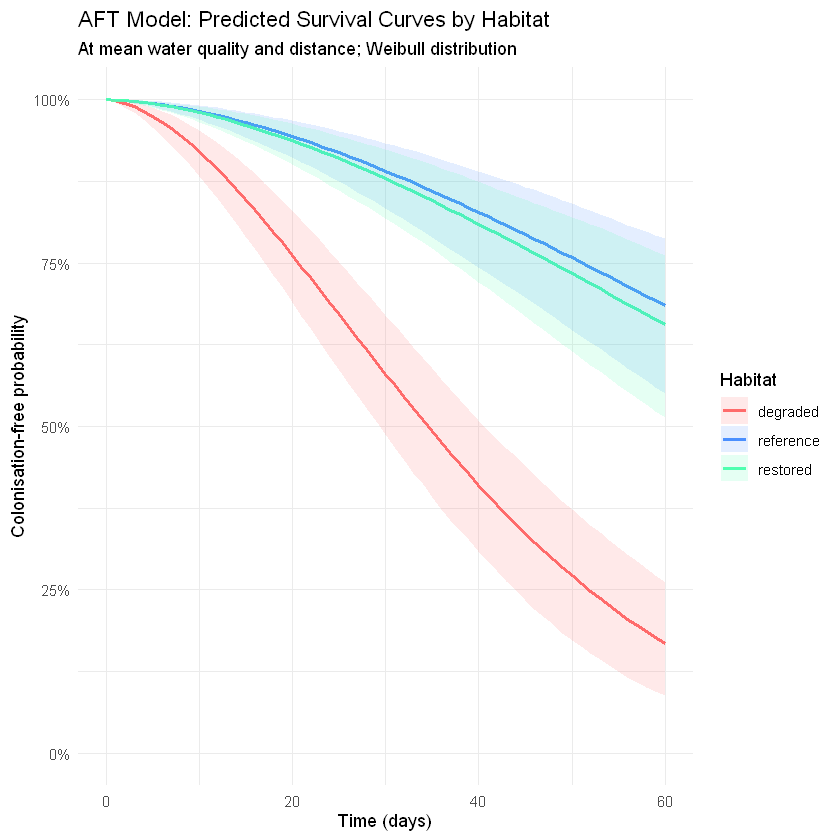

In [11]:
# Predicted survival curves for representative covariate profiles
newdata <- tibble(
  habitat     = factor(c("reference","restored","degraded"),
                       levels=levels(aft_data$habitat)),
  water_qual  = rep(mean(aft_data$water_qual), 3),
  distance_km = rep(mean(aft_data$distance_km), 3)
)

# Predicted survival at a grid of time points
t_grid <- seq(0, 60, by=1)
surv_pred <- summary(best_aft, newdata=newdata, t=t_grid, type="survival")

# Build plot data
pred_df <- map2_dfr(
  surv_pred,
  as.character(newdata$habitat),
  function(df, hab) mutate(as_tibble(df), habitat=hab)
)

pal <- c(reference="#4a8fff", restored="#4fffb0", degraded="#ff6b6b")

ggplot(pred_df, aes(x=time, y=est, color=habitat, fill=habitat)) +
  geom_line(linewidth=0.9) +
  geom_ribbon(aes(ymin=lcl, ymax=ucl), alpha=0.15, color=NA) +
  scale_color_manual(values=pal) +
  scale_fill_manual(values=pal) +
  scale_y_continuous(limits=c(0,1), labels=scales::percent) +
  labs(title="AFT Model: Predicted Survival Curves by Habitat",
       subtitle="At mean water quality and distance; Weibull distribution",
       x="Time (days)", y="Colonisation-free probability",
       color="Habitat", fill="Habitat") +
  theme_minimal()

---

## Common Pitfalls

**1. Choosing a distribution without comparing AIC or checking fit**  
Defaulting to Weibull without checking alternatives is the most common error. Always compare AIC across distributions and overlay predicted vs. KM curves visually. A good AIC rank means little if the survival curve shape is obviously wrong.

**2. Confusing time ratios and hazard ratios**  
For the Weibull model, TR = HR^(−1/shape). A TR > 1 means the event is delayed — the opposite direction to HR > 1. Always state which metric you are reporting and interpret it explicitly.

**3. Using `survreg()` for distribution comparison**  
Base `survreg()` supports a limited set of distributions and does not make it easy to overlay predicted survival on a KM plot. Use `flexsurvreg()` for distribution selection and diagnostics; use `survreg()` only when a specific distribution has already been selected.

**4. Extrapolating beyond the observed time range**  
AFT models can predict survival at any time — including well beyond the observed data. Such extrapolations are sensitive to the distributional assumption, which cannot be validated outside the data range. Always flag extrapolation in reports.

**5. Not checking whether the AFT assumption holds**  
AFT models assume that covariates act multiplicatively on the time axis. For Weibull AFT, this is equivalent to proportional hazards — both assumptions can be checked with the log-log plot. For log-normal and log-logistic, there is no equivalent simple check; inspect residual plots from `flexsurvreg()`.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*